In [4]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist


In [5]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()


In [6]:
X_train = (X_train.astype("float32") / 255.0).reshape(-1, 28*28)
X_test  = (X_test.astype("float32")  / 255.0).reshape(-1, 28*28)

In [7]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(784,)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10, activation='softmax')
])

In [8]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy']
)

In [9]:
history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=128,
    verbose=1
)

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.8148 - sparse_categorical_accuracy: 0.7177 - val_loss: 0.4302 - val_sparse_categorical_accuracy: 0.8403
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.4391 - sparse_categorical_accuracy: 0.8467 - val_loss: 0.3796 - val_sparse_categorical_accuracy: 0.8603
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.3929 - sparse_categorical_accuracy: 0.8599 - val_loss: 0.3560 - val_sparse_categorical_accuracy: 0.8710
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.3644 - sparse_categorical_accuracy: 0.8697 - val_loss: 0.3427 - val_sparse_categorical_accuracy: 0.8755
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.3446 - sparse_categorical_accuracy: 0.8775 - val_loss: 0.3369 - val_sparse_categorical_accuracy: 0.8777
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.3312 - sparse_categorical_accuracy: 0.8809 - val_loss: 0.3302 - val_sparse_categorical_accuracy: 0.8802
Epoc

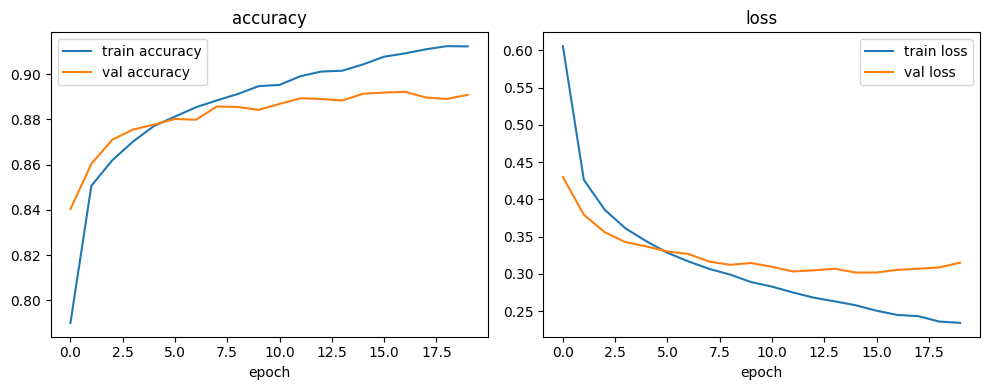

In [12]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['sparse_categorical_accuracy'], label='train accuracy')
plt.plot(history.history['val_sparse_categorical_accuracy'], label='val accuracy')
plt.title('accuracy'); plt.xlabel('epoch'); plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('loss'); plt.xlabel('epoch'); plt.legend()

plt.tight_layout(); plt.show()

In [14]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test loss: {test_loss:.4f} | Test accuracy: {test_acc:.4f}")

Test loss: 0.3406 | Test accuracy: 0.8849
